# PageRank 算法

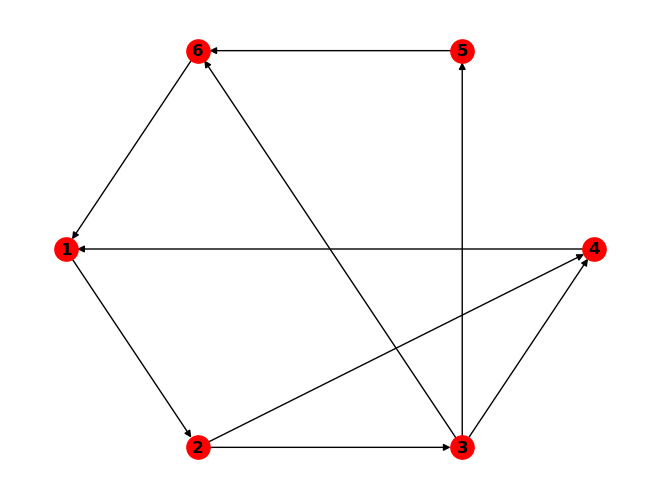

B(邻接矩阵) =
[[0. 1. 0. 0. 0. 0.]
 [0. 0. 1. 1. 0. 0.]
 [0. 0. 0. 1. 1. 1.]
 [1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0.]]
A(状态转移概率矩阵) =
[[0.025      0.875      0.025      0.025      0.025      0.025     ]
 [0.025      0.025      0.45       0.45       0.025      0.025     ]
 [0.025      0.025      0.025      0.30833333 0.30833333 0.30833333]
 [0.875      0.025      0.025      0.025      0.025      0.025     ]
 [0.025      0.025      0.025      0.025      0.025      0.875     ]
 [0.875      0.025      0.025      0.025      0.025      0.025     ]]
V(平稳分布) = [0.26752808 0.25239887 0.13226952 0.16974588 0.06247636 0.11558127]


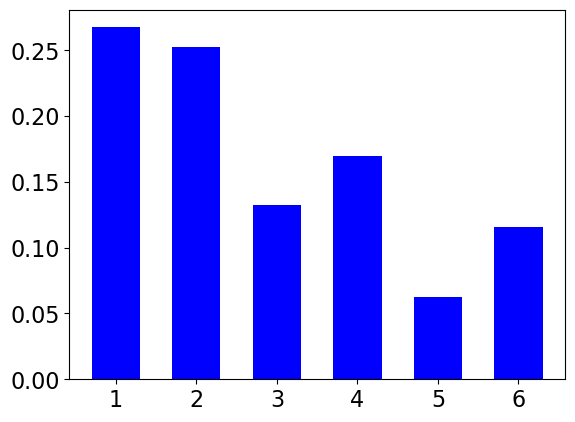

In [28]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigs

L = [(1, 2), (2, 3), (2, 4), (3, 4), (3, 5), (3, 6), (4, 1), (5, 6), (6, 1)]
G = nx.DiGraph()
G.add_nodes_from(range(1, 7))  # 添加顶点集
G.add_edges_from(L)  # 添加边集, 默认边存在的权值为1，不存在的为0，即超链接
B = nx.to_numpy_array(G)  # 提取邻接矩阵, 6x6

pos = nx.shell_layout(G)

plt.rcParams['font.size'] = 16
nx.draw(G, pos, node_size=280, font_weight='bold', node_color='r', with_labels=True)  # with_labels加箭头
plt.savefig("PageRank值网络结构图.png", dpi=500)
plt.show()

print(f"B(邻接矩阵) =\n{B}")
# B.sum(axis=1, keepdims=True)   axis=1每行求和，keepdims保留被求和的行,即返回[[1], [2], [3], [1], [1], [1]](shape为6x1，二维数组),若keepdims为False,返回[1, 2, 3, 1, 1, 1](shape为(6,),一维数组)
# np.tile([[1], [2], [3], [1], [1], [1]], (1, 6))  # 将[[1], [2], [3], [1], [1], [1]]当成一个元素，行扩展一次(即不扩展)，列扩展6次
A = B / np.tile(B.sum(axis=1, keepdims=True), (1, B.shape[1]))  # 计算b_{ij} / r_i(即 网页i跳转到网页j的链接 / 网页i跳转到其他可以跳转的网页的数目 )
A = 0.15 / B.shape[0] + 0.85 * A  # 计算状态转移概率矩阵A_{ij}, d = 0.85
print(f"A(状态转移概率矩阵) =\n{A}")

W, V = eigs(A.T, 1)  # eigenvalue(特征值), eigenvector(特征向量)，1表示计算一个最大特征值，返回的特征向量带有虚部(已归一化)
V = V.real  # 提取实部, 6x1 二维数组
V = V.flatten()  # 展开成(6,)形式的一维数组
V = V / V.sum()  # 计算马尔科夫链的平稳分布(概率分布)，各元素之和为1
print(f"V(平稳分布) = {V}")

plt.bar(range(1, B.shape[0]+1), V, width=0.6, color='b')
plt.savefig("PageRank值柱形图.png", dpi=500)
plt.show()